In [60]:
import pandas as pd
import numpy as np
import glob as glob
import math as math
import scipy.stats as stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
#import seaborn.apionly as sns
import matplotlib.patches as mpatches

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

import seaborn as sns
sns.set(color_codes = True)

from matplotlib import gridspec
from matplotlib import colors
from matplotlib import artist
from matplotlib import rc_context

from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import percentileofscore

%matplotlib inline

In [61]:
# read in RNA data
allRNAFile_paper = "OriginalData/GeneExpression.txt"
allRNADF_paper = pd.read_csv(allRNAFile_paper, sep="\t", low_memory=False,index_col=0)
genes_all = allRNADF_paper.columns.tolist()
hallmarks_gmt = "OriginalData/h.all.v2025.1.Hs.symbols.gmt"
fullDF = pd.read_csv("integrationpipeline_melanoma/integrated_data_melanoma.csv", index_col = 0)
# fullDF = pd.read_csv("synthesizers/gaussiancopula_42_IpiControl/synthetic_data_gaussiancopula_42.csv", index_col =0)
allRNADF = fullDF[genes_all]

In [38]:
# generate subset of RNAseq features
nanostringFile = 'OriginalData/addData/nanostring_genes.txt'
nanostringGenes = list(pd.read_csv(nanostringFile,sep="\t",low_memory=False, header=None)[0])
mangusoGeneFile = 'OriginalData/addData/manguso_genes.txt'
mangusoGenes = list(pd.read_csv(mangusoGeneFile,sep="\t",low_memory=False, header=None)[0])

genes = ['PRF1', 'GZMA', 'CD8A', 'IFNG', 'HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'CD274', 'PDCD1LG2',
         'PDCD1', 'CDKN2A', 'CDKN2B', 'FOXP3', 'TGFB1', 'ARG1', 'IDO1', 'IL12A', 
         'NOS2', 'JAK1', 'JAK2', 'STAT1', 'STAT2', 'STAT3', 'CXCL9', 'CXCL10', 'CXCR3', 'VEGFA', 'CSF3',
         'IL1A', 'IL1B', 'IL6', 'IL17A', 'CXCL1', 'IL2', 'LDHA']
TRegs = ['CD4', 'FOXP3', 'CTLA4', 'ICOS', 'TNFRSF18']
exhausted = ['TCF7']
activated = ['IL2RA', 'GZMK']
ifna = ['IFNA1', 'IFNA2', 'IFNA4', 'IFNA4', 'IFNA5', 'IFNA6', 'IFNA7', 'IFNA8', 'IFNA10', 'IFNA13', 'IFNA14',
      'IFNA16', 'IFNA17', 'IFNA21', 'IRF9', 'MX1', 'OAS3', 'SYK', 'PTK2B', 'USP18', 'PTPN11', 'TYK2',
       'IRF1', 'SOCS1', 'SOCS3', 'SIN3A']
ifn_inhibit = ['IL1A', 'IL1B', 'CSNK2A1', 'CSNK2A2']
ifng = ['IFNGR1', 'IFNAR1', 'IL15', 'IFNAR2', 'IFNGR2']
mhc1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
mhc2 = ['HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 
        'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 
        'HLA-DRB5']
chkpt = ['LAG3', 'HAVCR2', 'TNFRSF18', 'TNFRSF4', 'CTLA4', 'RGMB']
nk = ['TIGIT', 'KLRD1', 'NCAM1']
gamma_delta = ['TRDC']
cytokines = ['TNF', 'IFNB1']
glycolysis = ['PKM', 'GAPDH','CD44','ERO1B','GALE','GNE','NSDHL']
nad = ['NAMPT','NADK']
ppp = ['SHPK']
hypoxia = ['HIF1A']
faOxidation = ['IL4', 'STAT6', 'PPARGC1B', 'CPT1A']
aa = ['SLC1A5', 'NOS2', 'ARG1', 'IDO1']
apc = ['TAP1', 'TAP2', 'IFNAR1', 'NLRC5']
mapk = ['DUSP6', 'NF1', 'SPRED1', 'SPOP','RASA2']
nfkb = ['RELA', 'IKBKB', 'RNF31', 'OTULIN','SHARPIN', 'CFLAR']
mtorc1 = ['RRAGA','RRAGC','LAMTOR1']
pbaf = ['ARID2','PBRM1','BRD7']
wntDownstream = ['EFNB3','APC2','TCF7','MYC', 'TCF12', 'VEGFA']
melanoma = ['MITF', 'AXL']
EMT = ['CDH1', 'VIM', 'FN1', 'CDH2']
nerveGrowthFactor = ['NGFR']
melanoma_antigen = ['MAGEA1', 'MAGEA2B', 'MAGEA3', 'MAGEA4', 'MAGEA5', 'MAGEA6', 'MAGEA7P',
                   'MAGEA8', 'MAGEA9', 'MAGEA10', 'MAGEA11', 'MAGEA12']
otherGenes = ['TRIM22', 'TRIM38', 'IL32','SPATS2L','EPHA3','HERC3','ADAM19','SERPINB9',
         'IFI44L','F3','BEND6','AIG1','MSRB2','TNFRSF9','ANTXR1', 'TP53', 'PTPN14', 'PTPN7', 'SERPINA5', 'AXIN1']
erv = ['ERV3-1', 'DDX58', 'DHX58','IFIH1']
ldha = ['MYC', 'FOXM1', 'KLF4', 'ERBB2', 'HSF1', 'FGFR1', 'SIRT2']
angiogenesis = ['RASIP1', 'ARHGAP29', 'RHOA', 'ROCK1', 'CDC42', 'RAC1']

genes = list(set(genes + TRegs + exhausted + ifn_inhibit + ifna + ifng + mhc2 + mhc1
            + chkpt + nk + gamma_delta + activated + cytokines + glycolysis
            + ppp + hypoxia + faOxidation + aa + apc + erv + ldha + nad + mapk + nfkb + mtorc1 + pbaf
                + wntDownstream + melanoma + EMT + angiogenesis + nerveGrowthFactor+ mangusoGenes
                + melanoma_antigen + nanostringGenes))

genes = [x for x in genes if x in allRNADF.columns]

rnaDF = allRNADF[genes]

print(len(genes))

863


In [39]:
# generate response groups

responderCrit = fullDF['BR'].isin(['CR','PR'])
progressorCrit = fullDF['BR'].isin(['PD'])

responders = fullDF[responderCrit].index
progressors = fullDF[progressorCrit].index
nonresponders = fullDF[~responderCrit].index
nonprogressors = fullDF[~progressorCrit].index
print(len(responders),"responders")
print(len(progressors),"progressors")

fullDF.loc[responders,"PD vs Responder"] = 'Responder'
fullDF.loc[progressors,"PD vs Responder"] = 'Progressor'

fullDF.loc[responders,"Responder"] = 1
fullDF.loc[progressors,"Responder"] = 0

fullDF["PD vs nonPD"] = 'nonPD'
fullDF.loc[progressors,"PD vs nonPD"] = 'PD'

comparisonGroups = [
    'PD vs Responder',
    'PD vs nonPD',
]

fullDF['Responder'].value_counts()

47 responders
56 progressors


Responder
0.0    56
1.0    47
Name: count, dtype: int64

In [40]:
# generate additional columns
fullDF['log nonsyn mutload'] = [math.log(x,10) for x in fullDF['nonsyn_muts']]
fullDF['log clonal mutload'] = [math.log(x,10) for x in fullDF['clonal_muts']]
fullDF['log subclonal mutload'] = [math.log(x,10) for x in fullDF['subclonal_muts']]
fullDF['log neoantigens'] = [math.log(x,10) for x in fullDF['total_neoantigens']]

# add additional category
fullDF.loc[fullDF.index, 'Primary_Type_Categ'] = "Skin or Occult"
mucosalCrit = fullDF['Primary_Type'] == "mucosal"
acralCrit = fullDF['Primary_Type'] == "acral"
fullDF.loc[mucosalCrit | acralCrit, 'Primary_Type_Categ'] = "Mucosal or Acral"

# add dominant mutational signature
uvDom = (fullDF['UV'] > fullDF['Alkylating']) & (fullDF['UV'] > fullDF['Cosmic'])
alkDom = (fullDF['Alkylating'] > fullDF['UV']) & (fullDF['Alkylating'] > fullDF['Cosmic'])
otherDom = (fullDF['Cosmic'] > fullDF['Alkylating']) & (fullDF['Cosmic'] > fullDF['UV'])

print(sum(uvDom), "tumors with dominant UV signature")
print(sum(alkDom), "tumors with dominant alkylating signature")
print(sum(otherDom), "tumors with dominant other (aging + others) signature")

# add to tumorDF
fullDF.loc[uvDom,"Dominant MutSig"] = 'UV'
fullDF.loc[alkDom,"Dominant MutSig"] = 'Alkylating'
fullDF.loc[otherDom,'Dominant MutSig'] = 'Other'

85 tumors with dominant UV signature
3 tumors with dominant alkylating signature
33 tumors with dominant other (aging + others) signature


In [41]:
import gseapy as gp
overall_df = fullDF[~fullDF["PD vs Responder"].isna()]
cohort = list(overall_df.index)
# rnaDF_T = rnaDF.T.reset_index()
# rnaDF_T.columns.values[0] = 'Gene'
# allRNADF_overall = pd.concat([rnaDF_T["Gene"], rnaDF_T[cohort]], axis = 1)

In [59]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests


phenotype = "PD vs Responder"
responders_df = overall_df[overall_df[phenotype]=="Responder"]
progressor_df = overall_df[overall_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in allRNADF.columns.tolist():
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    if np.mean(progressors_exp) == 0:
        print(gene)
        progressors_exp = 10e-9
        pass
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":allRNADF.columns.tolist(), "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
# results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Pvalue"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

In [ ]:

rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_overall = pre_res.res2d

In [50]:
print("---Ipi-Experience---")
phenotype = "PD vs Responder"
ipitreated_df = overall_df[overall_df["daysBiopsyAfterIpiStart"]=="postIpi"]
responders_df = ipitreated_df[ipitreated_df[phenotype]=="Responder"]
progressor_df = ipitreated_df[ipitreated_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in allRNADF.columns.tolist():
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":allRNADF.columns.tolist(), "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
# results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Pvalue"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
ipitreated_pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_ipitreated = ipitreated_pre_res.res2d
prerank_ipitreated.head()

---Ipi-Experience---


/tmp/ipykernel_265917/2861483751.py:13: RuntimeWarning: divide by zero encountered in log2
  log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
2025-11-20 12:04:39,033 [WARNING] Duplicated values found in preranked stats: 98.86% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-20 12:04:39,034 [INFO] Parsing data files for GSEA.............................
2025-11-20 12:04:39,069 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-20 12:04:39,070 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-20 12:04:39,071 [INFO] Start to run GSEA...Might take a while..................
2025-11-20 12:04:48,855 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_ALLOGRAFT_REJECTION,0.595491,2.472535,0.0,0.0,0.0,87/190,14.23%,PRKCB;CD28;CTSS;HLA-DMA;CXCR3;TAP2;CD3D;ETS1;M...
1,prerank,HALLMARK_INTERFERON_GAMMA_RESPONSE,0.56275,2.339243,0.0,0.0,0.0,92/194,19.11%,HLA-DMA;PFKP;OASL;SECTM1;CMPK2;IL2RB;IL10RA;IT...
2,prerank,HALLMARK_INTERFERON_ALPHA_RESPONSE,0.587654,2.217362,0.0,0.0,0.0,44/94,19.11%,OASL;CMPK2;TRIM26;CMTR1;RSAD2;CCRL2;IFI30;B2M;...
3,prerank,HALLMARK_INFLAMMATORY_RESPONSE,0.445558,1.857098,0.0,0.000626,0.0022,58/197,15.23%,SLAMF1;P2RX4;MARCO;CYBB;PIK3R5;FZD5;IL2RB;IL10...
4,prerank,HALLMARK_IL2_STAT5_SIGNALING,0.41702,1.739945,0.0,0.002981,0.013,60/196,16.51%,CCR4;CTLA4;NOP2;PRKCH;P2RX4;ICOS;IL2RB;IL10RA;...


In [51]:
print("---Ipi-Naive---")
phenotype = "PD vs Responder"
ipitreated_df = overall_df[overall_df["daysBiopsyAfterIpiStart"]=="noIpi"]
responders_df = ipitreated_df[ipitreated_df[phenotype]=="Responder"]
progressor_df = ipitreated_df[ipitreated_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in allRNADF.columns.tolist():
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":allRNADF.columns.tolist(), "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
ipinaive_pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_ipinaive = ipinaive_pre_res.res2d
prerank_ipinaive.head()

---Ipi-Naive---


2025-11-20 12:05:37,617 [WARNING] Duplicated values found in preranked stats: 99.32% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-20 12:05:37,618 [INFO] Parsing data files for GSEA.............................
2025-11-20 12:05:37,651 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-20 12:05:37,652 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-20 12:05:37,653 [INFO] Start to run GSEA...Might take a while..................
2025-11-20 12:05:47,403 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_E2F_TARGETS,0.435432,2.797962,0.0,0.0,0.0,88/198,22.29%,EXOSC8;HMMR;NCAPD2;CTPS1;MCM2;MLH1;NOLC1;MXD3;...
1,prerank,HALLMARK_G2M_CHECKPOINT,0.405867,2.60077,0.0,0.0,0.0,91/193,24.20%,CUL4A;HNRNPU;HMMR;MCM2;NUP50;NOLC1;SFPQ;RACGAP...
2,prerank,HALLMARK_ALLOGRAFT_REJECTION,0.33207,2.099422,0.0,0.002357,0.0007,100/190,33.48%,MMP9;CAPG;FLNA;CFP;IL16;IRF8;CDKN2A;CSF1;ITGB2...
3,prerank,HALLMARK_MYC_TARGETS_V2,0.413387,2.090795,0.0,0.001767,0.0007,18/57,16.39%,RCL1;NOLC1;MPHOSPH10;NOP2;RRP12;NOP56;HK2;RABE...
4,prerank,HALLMARK_MTORC1_SIGNALING,0.317306,2.060165,0.0,0.00202,0.001,80/194,24.28%,MAP2K3;PSMC6;MCM2;NMT1;HPRT1;PSME3;ENO1;CD9;CF...


In [52]:
pathways = ["HALLMARK_INTERFERON_GAMMA_RESPONSE","HALLMARK_INTERFERON_ALPHA_RESPONSE"]
subgroups = ["Overall","Ipi-Exp","Ipi-Naive"]
graphDFs = []
for pathway in pathways:
    print(pathway)
    overall_qvalue = prerank_overall[prerank_overall["Term"]==pathway]["FDR q-val"].values
    ipitreated_qvalue = prerank_ipitreated[prerank_ipitreated["Term"]==pathway]["FDR q-val"].values
    ipinaive_qvalue = prerank_ipinaive[prerank_ipinaive["Term"]==pathway]["FDR q-val"].values
    graphDF = pd.DataFrame(
        {"Subgroup": subgroups,
         "FDR q-value": [float(overall_qvalue), float(ipitreated_qvalue), float(ipinaive_qvalue)],
         "Pathway": [pathway]*len(subgroups)
        }
    ) 
    # generate the visualization
    qval = []
    for x in graphDF["FDR q-value"]:
        if x == 0:
            qval += [4] # 10^-4 is the limit for our q-values
        elif x == 1:
            qval += [0.1] # for visualization purposes
        else:
            q = -math.log(x,10)
            if q < 0.1:
                q = 0.1 # for visualization purposes
            qval += [q]
    graphDF["-Log10Qvalue"] = qval
    graphDFs.append(graphDF)
graphDF_final = pd.concat(graphDFs, axis = 0)

HALLMARK_INTERFERON_GAMMA_RESPONSE
HALLMARK_INTERFERON_ALPHA_RESPONSE


0 HALLMARK_INTERFERON_GAMMA_RESPONSE
1 HALLMARK_INTERFERON_ALPHA_RESPONSE


/tmp/ipykernel_265917/166890768.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend on the right


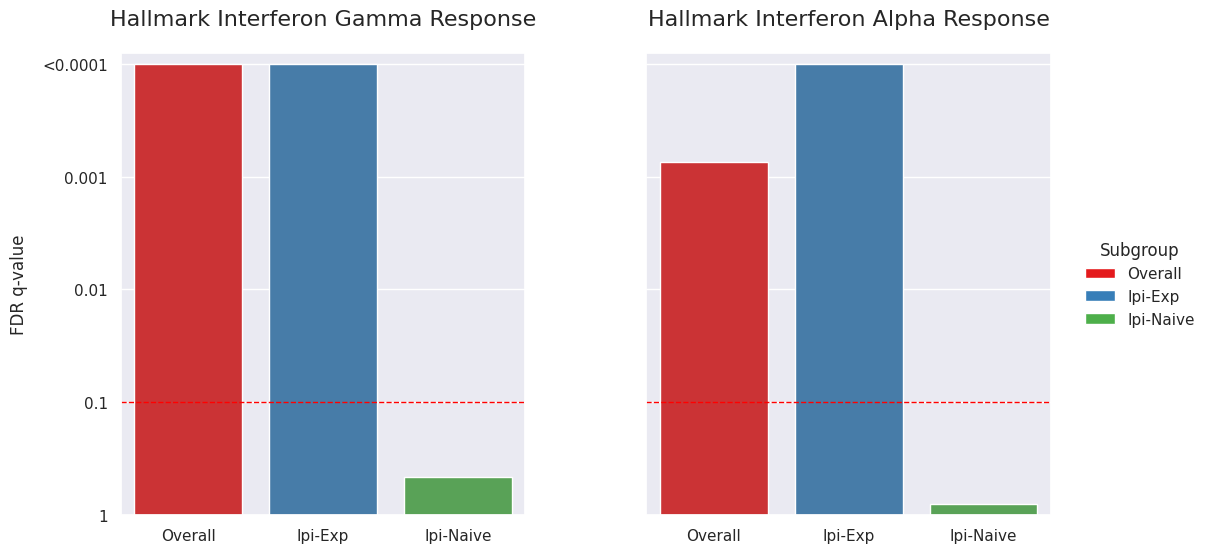

In [53]:
from matplotlib.patches import Rectangle
fig = plt.figure(figsize=(12, 6)) 
nrows = 1
ncols = 2
# No need for height_ratios or width_ratios for a simple 1x2 grid unless specific proportions are needed.
gs = gridspec.GridSpec(nrows, ncols, wspace=0.3) # Increased wspace for more gap between plots

# Define a color palette for the subgroups to match your image
# Assuming 'Overall' is red, 'Ipi-Exp' is blue, 'Ipi-Naive' is green
custom_palette = {'Overall': '#E41A1C', 'Ipi-Exp': '#377EB8', 'Ipi-Naive': '#4DAF4A'}

# Define the custom legend handles and labels based on your desired order
legend_labels = subgroups # ['Overall', 'Ipi-Exp', 'Ipi-Naive']
legend_handles = [Rectangle((0, 0), 1, 1, fc=custom_palette[subgroup]) 
                  for subgroup in legend_labels]
for i, pathway in enumerate(pathways):
    print(i, pathway)
    ax = plt.subplot(gs[0, i]) # Access subplots in the first row
    
    # Filter data for the current pathway
    plot_data = graphDF_final[graphDF_final["Pathway"] == pathway]

    sns.barplot(ax=ax, 
                x='Subgroup', 
                y='-Log10Qvalue', 
                hue='Subgroup', 
                data=plot_data, 
                dodge=False, # Important: prevents bars from shifting if x and hue are the same
                palette=custom_palette # Apply custom colors
               )
    
    # Set titles for each subplot
    title = pathway.replace("_", " ").title()
    ax.set_title(title, fontsize=16, pad=20) # Pad adds space between title and plot

    # Y-axis ticks and labels
    yticks_val = [0, 1, 2, 3, 4]
    yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
    ax.set_yticks(yticks_val)
    ax.set_yticklabels(yticklabels_val)
    
    # Significance line at -Log10(0.1) = 1
    yline = 1.0 
    xlim_max = len(subgroups) - 0.5 # For 3 subgroups, x goes from -0.5 to 2.5
    ax.plot([-0.5, xlim_max], [yline, yline], color='red', linestyle='--', linewidth=1)
    
    # Set X and Y limits
    ax.set_xlim(-0.5, xlim_max)
    ax.set_ylim(0, 4.1) # Start y-axis from 0 to avoid cut-off at the bottom
    
    # X-axis label
    ax.set_xlabel("")
    
    # Y-axis label only for the first subplot
    if i == 0:
        ax.set_ylabel("FDR q-value", labelpad=10)
    else:
        ax.set_ylabel("") # Hide y-label for the second subplot
        ax.tick_params(axis='y', labelleft=False) # Hide y-tick labels as well
        
    if i == 1:
        ax.legend(legend_handles, legend_labels, 
          loc='center left', 
          bbox_to_anchor=(1.05, 0.5), 
          title="Subgroup", 
          frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend on the right
plt.show()

## **ssGSEA**

In [534]:
import gseapy as gp

def load_gmt_as_dict(gmt_file):
    gene_sets = {}
    with open(gmt_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            set_name = parts[0]
            # parts[1] is description (often ignored)
            # Upper-case genes and remove any empty strings / duplicates
            genes = [g.strip().upper() for g in parts[2:] if g.strip()]
            # preserve order but remove duplicates
            seen = set()
            genes_unique = []
            for g in genes:
                if g not in seen:
                    seen.add(g)
                    genes_unique.append(g)
            gene_sets[set_name] = genes_unique
    return gene_sets

mhc_ii = [
    "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5"
]
mhc_i = ["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "TAP1", "TAP2", "B2M"]

hallmarks_gmt = "OriginalData/h.all.v2025.1.Hs.symbols.gmt"
gmt_dict = load_gmt_as_dict(hallmarks_gmt)  # returns dict with upper-cased genes

# add custom sets as upper-cased lists
gmt_dict["MHC-II"] = [g.upper() for g in mhc_ii]
gmt_dict["MHC-I"] = [g.upper() for g in mhc_i]
ssgsea_res = gp.ssgsea(
    data=allRNADF.T,
    gene_sets=gmt_dict,
    # sample_norm_method='rank',
    outdir=None,
    permutation_num=0,
    no_plot=True,
    min_size=1,
    max_size=10000
)
res2d = ssgsea_res.res2d

res_wide = res2d.pivot(index="Name", columns="Term", values="ES")

In [488]:
allrnaDF_T = allRNADF.T.reset_index()
allrnaDF_T.columns.values[0] = 'Gene'
allrnaDF_T

Patient,Gene,Patient1,Patient10,Patient100,Patient102,Patient105,Patient106,Patient107,Patient108,Patient11,...,Patient8,Patient82,Patient83,Patient86,Patient87,Patient9,Patient94,Patient96,Patient98,Patient99
0,SSX1,1.107247,0.189621,0.000000,0.162085,0.000000,14.182133,0.000000,3.636255,0.520234,...,11.225737,1.604258,4.364315,0.019665,0.000000,0.166007,0.434913,0.000000,0.889202,4.492280
1,ANKRD17,81.154718,102.509285,65.140391,83.126624,100.340992,80.080351,142.109505,119.238874,115.752161,...,94.868987,103.439781,213.043847,74.469488,85.100995,88.288189,83.692338,39.475677,152.660869,65.886773
2,IL13,0.000000,0.000000,0.000000,0.069465,0.000000,0.095023,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.058994,0.057089,0.000000,0.000000,0.051401,0.000000,0.000000
3,ITGA1,1.856268,37.222665,57.787250,27.554508,3.380761,17.911772,6.636171,0.833309,387.618004,...,13.220287,27.533954,5.120338,27.019033,17.887955,10.403121,16.413229,3.032637,48.819380,31.938784
4,MAGEA6,0.000000,0.056886,3.201607,20.075427,1.893226,13.873309,25.567439,0.000000,50.245976,...,0.409138,32.521104,17.972729,4.365521,0.000000,1.300390,26.813316,46.877366,0.043376,0.132683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
858,SHPK,1.595739,2.806396,1.530439,1.412458,0.622060,3.397060,0.000000,0.000000,1.777468,...,2.480402,1.412445,1.288676,1.868128,2.017152,4.177849,2.647295,1.285016,2.580856,2.103979
859,C7,1.107247,14.657728,7.828105,21.997296,0.000000,4.537332,2.999913,0.000000,1.929203,...,22.604901,1.900697,0.601382,17.835708,2.093271,3.237141,0.699642,1.439217,20.473343,12.889242
860,IL23A,0.293095,0.075849,0.404599,0.740962,0.216369,0.071267,0.000000,0.000000,0.151735,...,0.025571,0.296439,0.103094,0.098323,0.209327,0.249011,0.340366,0.257003,0.260254,0.227457
861,GTF2F1,23.415025,38.019075,35.710233,35.079899,16.687437,33.733046,14.795024,6.969489,31.647595,...,28.051557,20.175291,40.911154,17.304766,26.927081,44.047257,24.374023,11.719342,28.541228,33.891125


In [489]:
# allrnaDF_T.to_csv("cibersort/or_GeneExpression_Melanoma.txt", sep="\t", index=False)

## **Figure 4**

In [536]:
def PlotStackedBarPlot(barPlot, df_nonnorm, sigOrder = None, xlabel = False, colorList = PRIMARY_SIG_COLORS, 
                       normalize = False, legendSize = 50):
    numSamples = len(df_nonnorm.columns)
    numClasses = len(df_nonnorm)

#    plt.figure(figsize=(30,10))

    if normalize: 
        # normalize data
        df = df_nonnorm/df_nonnorm.apply(sum, axis = 0)
    else:
        df = df_nonnorm

    # set order
    if sigOrder is None: # set signature order to default order
        sigOrder = df_nonnorm.index    
    df = df.loc[sigOrder]
    
    # generate the bottoms of each of the stacked values
    bottom = [np.array([0] * numSamples)]
    for i in range(0, numClasses):
        bottom.append(bottom[i] + np.array(df.iloc[i,:]))
    
    ind = np.arange(numSamples)
    width = 0.5
    bargraphs = []
    
    for i in range(0, numClasses):
        bargraphs.append(plt.bar(ind, df.iloc[i,:], width, bottom = bottom[i], color = colorList[i+1]))

    # label x axis
    if xlabel:
        plt.setp(barPlot.get_xticklabels(), visible=True)
        plt.xticks(ind, df.columns, rotation = 'vertical')
#        barPlot.get_xaxis().set_ticks(ind + width/2., df.columns, rotation = 'vertical')
    else:
        plt.setp(barPlot.get_xticklabels(), visible=False)

    # Limit x axis
    plt.xlim(-0.5, numSamples-0.5)
        
#        barPlot.get_xaxis().set_ticks(ind + width/2., [])
    
    # label y axis
    barPlot.get_yaxis().set_label("Mutations")
    
    
    # Legend
    if legendSize is not None:
        barPlot.legend([x[0] for x in bargraphs[::-1]], sigOrder[::-1], prop = {'size':legendSize}, 
                        bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [535]:
fullDF_4 = pd.concat([fullDF, res_wide], axis = 1)

# generate MHC-II upper (above median) and MHC-II lower (below median) groups
medianMHCII = fullDF_4["MHC-II"].median()
upperMHCII = list(fullDF_4.loc[fullDF_4["MHC-II"]>=medianMHCII].index)
lowerMHCII = list(fullDF_4.loc[fullDF_4["MHC-II"]<medianMHCII].index)

postIpi = fullDF_4[fullDF_4["PostIpi"]==1].index
noIpi = fullDF_4[fullDF_4["IpiTreated"]==0].index
ipiExpUpperMHCII = [x for x in postIpi if x in upperMHCII]
ipiExpLowerMHCII = [x for x in postIpi if x in lowerMHCII]
ipiNaiveUpperMHCII = [x for x in noIpi if x in upperMHCII]
ipiNaiveLowerMHCII = [x for x in noIpi if x in lowerMHCII]
print("MHCII", medianMHCII, len(upperMHCII), len(lowerMHCII), len(ipiExpUpperMHCII),len(ipiExpLowerMHCII),len(ipiNaiveUpperMHCII),len(ipiNaiveLowerMHCII))

MHCII 5412.212586926198 61 60 21 13 37 38


[[28, 19], [23, 33]]
MHC-II R vs. PD: p = 0.07617490311145005 (Fisher)
MHC-II R vs. PD: OR =  2.11441647597254
[[9, 2], [7, 9]]
Ipi-Exp MHC-II R vs. PD: p = 0.10902319737963835 (Fisher)
Ipi-Exp MHC-II R vs. PD: OR =  5.785714285714286
[[17, 14], [15, 19]]
Ipi-Naive MHC-II R vs. PD: p = 0.4602970190306581 (Fisher)
Ipi-Naive MHC-II R vs. PD: OR =  1.5380952380952382


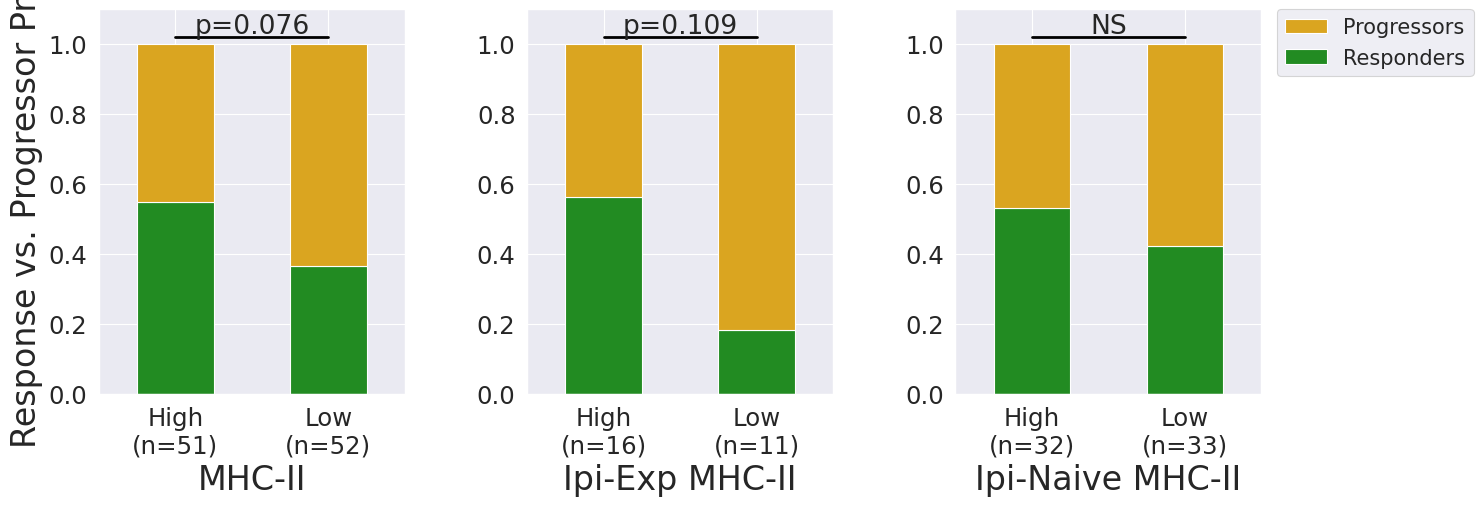

In [537]:
# Fig 4abc - proportion of responders/progressors based on high/low MHC-II expression (median split)
# in the overall, ipi-experienced, and ipi-naive cohort.
cohort = ~fullDF_4[phenotype].isnull() # either Responder (CR,PR) or (PD)

groups = ['MHC-II', 'Ipi-Exp MHC-II', 'Ipi-Naive MHC-II']

tempDF = fullDF_4[cohort][['Responder']]
comparisonGroups = {'MHC-II':[upperMHCII, lowerMHCII],
                   'Ipi-Exp MHC-II':[ipiExpUpperMHCII, ipiExpLowerMHCII],
                   'Ipi-Naive MHC-II':[ipiNaiveUpperMHCII, ipiNaiveLowerMHCII]}
                   # 'Absolute score':[upperAS, lowerAS],
                   # 'Ipi-Naive Absolute score':[ipiNaiveUpperAS, ipiNaiveLowerAS],
                   # 'Ipi-Exp Absolute score':[ipiExpUpperAS, ipiExpLowerAS]}

ncols = len(groups)
nrows = 1
gs = gridspec.GridSpec(nrows,ncols, #height_ratios = [1, ], width_ratios = [1,1,1], 
                       wspace=0.4, hspace = 0.4)

fig = plt.figure(figsize=(5*ncols,5))
sns.set_context("paper",font_scale=2)

i = 0
for group in groups:
    ax = plt.subplot(gs[i])
    upper = comparisonGroups[group][0]
    lower = comparisonGroups[group][1]
    upperResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(upper)))
    upperNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(upper)))
    lowerResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(lower)))
    lowerNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(lower)))
    graphDF = pd.DataFrame([[upperResponders,
                       upperNonresponders],
                       [lowerResponders,
                       lowerNonresponders]], 
                       index = ['High', 'Low'],
                      columns = ['Responders', 'Progressors']).transpose()

    orderedCategories = {
                    'MHC-II':['High', 'Low'],
                    'Ipi-Exp MHC-II':['High', 'Low'],
                    'Ipi-Naive MHC-II':['High', 'Low']}
                    # 'Absolute score':['High','Low'],
                    # 'Ipi-Exp Absolute score':['High','Low'],
                    # 'Ipi-Naive Absolute score':['High','Low']}

    if group in orderedCategories:
        groupOrder = orderedCategories[group]
    else:
        groupOrder = graphDF.columns
    colorList = [GRAY, RESPONDER_COL, NRESPONDER_COL]

    categories = ['Responders', 'Progressors']
    if i == len(groups) - 1: # only display if last one
        legendSize = 15
    else:
        legendSize = None # 
        
    PlotStackedBarPlot(ax, graphDF.loc[categories, groupOrder], xlabel=True, sigOrder = categories, normalize=True, 
                    colorList=colorList,legendSize=legendSize)
    plt.xlabel(group, fontsize=24)
    xlabels = []
    for label in groupOrder:
        total = graphDF[label].sum()
        xlabels += [label + "\n(n=" + str(total)+")"]
    ax.set_xticklabels(xlabels,rotation=0)
    if i == 0:
        plt.ylabel("Response vs. Progressor Prop", fontsize=24)
    
    # statistically compare values
    fishersMatrix = [[graphDF.loc['Responders', 'High'], graphDF.loc['Responders', 'Low']], 
                        [graphDF.loc['Progressors', 'High'], graphDF.loc['Progressors', 'Low']]]
    print(fishersMatrix)
    oddsratio, pval_fisher = stats.fisher_exact(fishersMatrix)
       
    print(group, "R vs. PD: p =", pval_fisher, "(Fisher)")
    print(group, "R vs. PD: OR = ", oddsratio )

    # plot the significance comparison
    sig = "NS"
    if pval_fisher <= 0.15:
        sig = "p=" + "{:.3f}".format(pval_fisher)
    if pval_fisher <= 0.05:
        sig = "*"
    if pval_fisher <= 0.01:
        sig = "**"
    if pval_fisher <= 0.001:
        sig = "***"
    
    yMax = 1
    plt.plot([0,1],[yMax * 1.02,yMax * 1.02], lw=2, color="black")  
   
    plt.text(0.5,yMax * 1.03,sig, ha='center')
    plt.ylim(0,yMax * 1.1)

    i+=1

In [493]:
immune_decovolution = pd.read_csv("cibersort/CIBERSORTx_Melanoma_rerun_Results.csv", index_col = 0)
immune_decovolution.head()

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
Mixture,,,,,,,,,,,,,,,,,,,,,
Patient100,0.094945,0.169995,0.222547,1.921739,0.0,0.000000,1.389929,0.748019,0.035093,0.000132,...,0.108004,0.000000,0.206147,0.000000,0.000000,0.000000,0.001,0.422651,0.905691,7.512902
Patient102,0.181947,0.000000,0.031108,0.091714,0.0,0.527728,0.076247,0.000000,0.000000,0.000000,...,0.000000,0.001246,0.048597,0.015323,0.000000,0.015829,0.001,0.448470,0.893604,2.300275
Patient105,0.010042,0.043173,0.007021,0.219642,0.0,0.242395,0.052428,0.113586,0.007072,0.000000,...,0.060972,0.007049,0.020802,0.010595,0.045420,0.001145,0.004,0.336987,0.945341,1.281456
Patient106,0.038641,0.089592,0.055319,0.232135,0.0,0.175023,0.153997,0.068581,0.000000,0.000000,...,0.000000,0.000000,0.078324,0.000000,0.039677,0.000000,0.000,0.558996,0.831480,2.628326
Patient107,0.000000,0.166607,0.000000,0.047566,0.0,0.167703,0.233750,0.030825,0.034545,0.000000,...,0.041037,0.015966,0.065451,0.027466,0.000000,0.024800,0.075,0.139192,1.023452,1.342158


In [494]:
# generate absolute score (estimate of immune infiltrate) upper and lower cohorts (median split)
fullDF_4_cibersort = pd.concat([fullDF, immune_decovolution], axis = 1)
medianAbsoluteScore = fullDF_4_cibersort['Absolute score (sig.score)'].median()
upperAS = list(fullDF_4_cibersort.loc[fullDF_4_cibersort['Absolute score (sig.score)']>=medianAbsoluteScore].index)
lowerAS = list(fullDF_4_cibersort.loc[fullDF_4_cibersort['Absolute score (sig.score)']<medianAbsoluteScore].index)

ipiExpUpperAS = [x for x in postIpi if x in upperAS]
ipiExpLowerAS = [x for x in postIpi if x in lowerAS]
ipiNaiveUpperAS = [x for x in noIpi if x in upperAS]
ipiNaiveLowerAS = [x for x in noIpi if x in lowerAS]


print("Absolute score:",medianAbsoluteScore, len(upperAS), len(lowerAS), len(ipiExpUpperAS),\
    len(ipiExpLowerAS),len(ipiNaiveUpperAS),len(ipiNaiveLowerAS))

Absolute score: 2.45169290261102 61 60 22 12 35 40


[[25, 22], [25, 31]]
Absolute score R vs. PD: p = 0.43230423779174 (Fisher)
Absolute score R vs. PD: OR =  1.4090909090909092
[[9, 2], [9, 7]]
Ipi-Exp Absolute score R vs. PD: p = 0.2311212814645309 (Fisher)
Ipi-Exp Absolute score R vs. PD: OR =  3.5
[[14, 17], [15, 19]]
Ipi-Naive Absolute score R vs. PD: p = 1.0 (Fisher)
Ipi-Naive Absolute score R vs. PD: OR =  1.0431372549019609


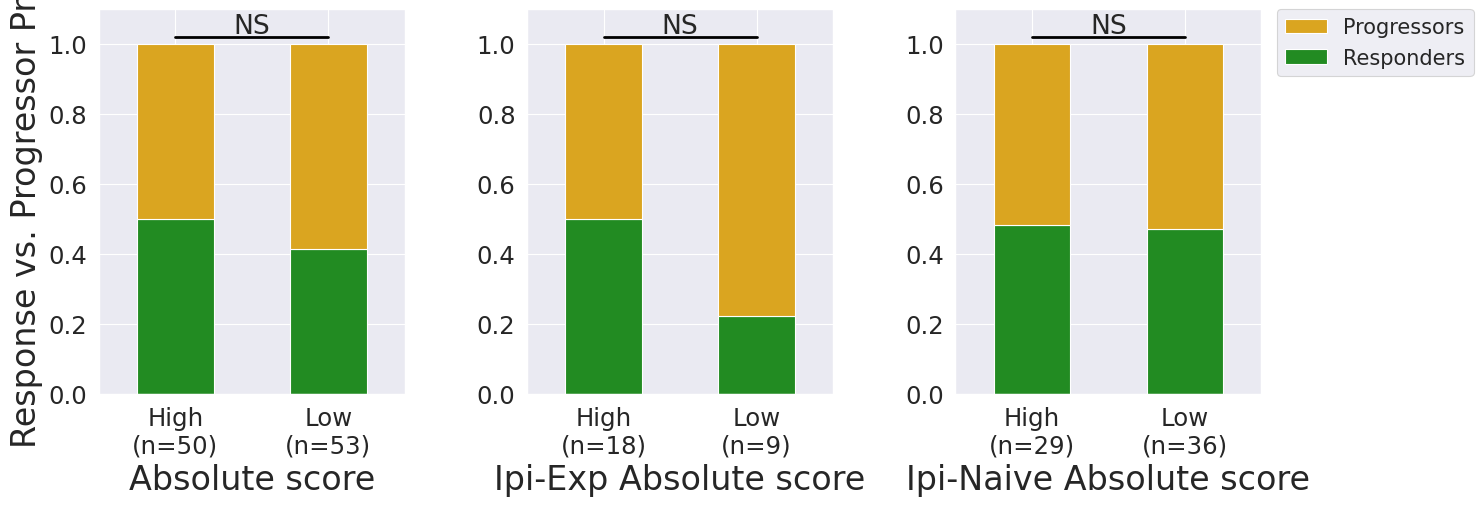

In [495]:
cohort = ~fullDF_4_cibersort[phenotype].isnull() # either Responder (CR,PR) or (PD)

groups = ['Absolute score', 'Ipi-Exp Absolute score', 'Ipi-Naive Absolute score']

tempDF = fullDF_4_cibersort[cohort][['Responder']]
comparisonGroups = {'MHC-II':[upperMHCII, lowerMHCII],
                   'Ipi-Exp MHC-II':[ipiExpUpperMHCII, ipiExpLowerMHCII],
                   'Ipi-Naive MHC-II':[ipiNaiveUpperMHCII, ipiNaiveLowerMHCII],
                   'Absolute score':[upperAS, lowerAS],
                   'Ipi-Naive Absolute score':[ipiNaiveUpperAS, ipiNaiveLowerAS],
                   'Ipi-Exp Absolute score':[ipiExpUpperAS, ipiExpLowerAS]}

ncols = len(groups)
nrows = 1
gs = gridspec.GridSpec(nrows,ncols, #height_ratios = [1, ], width_ratios = [1,1,1], 
                       wspace=0.4, hspace = 0.4)

fig = plt.figure(figsize=(5*ncols,5))
sns.set_context("paper",font_scale=2)

i = 0
for group in groups:
    ax = plt.subplot(gs[i])
    upper = comparisonGroups[group][0]
    lower = comparisonGroups[group][1]
    upperResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(upper)))
    upperNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(upper)))
    lowerResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(lower)))
    lowerNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(lower)))
    graphDF = pd.DataFrame([[upperResponders,
                       upperNonresponders],
                       [lowerResponders,
                       lowerNonresponders]], 
                       index = ['High', 'Low'],
                      columns = ['Responders', 'Progressors']).transpose()
    # print graphDF

    orderedCategories = {
                    'MHC-II':['High', 'Low'],
                    'Ipi-Exp MHC-II':['High', 'Low'],
                    'Ipi-Naive MHC-II':['High', 'Low'],
                    'Absolute score':['High','Low'],
                    'Ipi-Exp Absolute score':['High','Low'],
                    'Ipi-Naive Absolute score':['High','Low']}

    if group in orderedCategories:
        groupOrder = orderedCategories[group]
    else:
        groupOrder = graphDF.columns
    colorList = [GRAY, RESPONDER_COL, NRESPONDER_COL]

    categories = ['Responders', 'Progressors']
    if i == len(groups) - 1: # only display if last one
        legendSize = 15
    else:
        legendSize = None # 
        
    PlotStackedBarPlot(ax, graphDF.loc[categories, groupOrder], xlabel=True, sigOrder = categories, normalize=True, 
                    colorList=colorList,legendSize=legendSize)
    plt.xlabel(group, fontsize=24)
    xlabels = []
    for label in groupOrder:
        total = graphDF[label].sum()
        xlabels += [label + "\n(n=" + str(total)+")"]
    ax.set_xticklabels(xlabels,rotation=0)
    if i == 0:
        plt.ylabel("Response vs. Progressor Prop", fontsize=24)
    
    # statistically compare values
    fishersMatrix = [[graphDF.loc['Responders', 'High'], graphDF.loc['Responders', 'Low']], 
                        [graphDF.loc['Progressors', 'High'], graphDF.loc['Progressors', 'Low']]]
    print(fishersMatrix)
    oddsratio, pval_fisher = stats.fisher_exact(fishersMatrix)
       
    print(group, "R vs. PD: p =", pval_fisher, "(Fisher)")
    print(group, "R vs. PD: OR = ", oddsratio)

    # plot the significance comparison
    sig = "NS"
    if pval_fisher <= 0.15:
        sig = "p=" + "{:.3f}".format(pval_fisher)
    if pval_fisher <= 0.05:
        sig = "*"
    if pval_fisher <= 0.01:
        sig = "**"
    if pval_fisher <= 0.001:
        sig = "***"
    
    yMax = 1
    plt.plot([0,1],[yMax * 1.02,yMax * 1.02], lw=2, color="black")  
   
    plt.text(0.5,yMax * 1.03,sig, ha='center')
    plt.ylim(0,yMax * 1.1)

    i+=1

## **Figure 5**

In [538]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [539]:
res_wide = res_wide.astype(float)
quantVars = [
            'log nonsyn mutload',
              'heterogeneity',
              'purity',
                'ploidy',
               'Tx_Start_LDH',
                ]

categVars = [
                'LN_Met',
            ]

# generate response groups stratified by prior ipilimumab treatment status
# Generate a category for allRNADF to compare nonresponders (ipi-experienced) vs nonresponders (ipi-naive)
ipiTreated = fullDF[fullDF["IpiTreated"]==1].index
postIpi = list(fullDF[fullDF["PostIpi"]==1].index)
preIpi = list(fullDF[fullDF["PreIpi"]==1].index)
noIpi = list(fullDF[fullDF["IpiTreated"]==0].index)


PDpostIpi = list(set(postIpi).intersection(set(progressors)))
PDnoIpi = list(set(noIpi).intersection(set(progressors)))
RpostIpi = list(set(postIpi).intersection(set(responders)))
RnoIpi = list(set(noIpi).intersection(set(responders)))
nPDpostIpi = [x for x in postIpi if x not in progressors] 
nPDnoIpi = [x for x in noIpi if x not in progressors] 

# create a set of regression DFs for each comparison and cohort, e.g. regDFs['Ipi-exp PDvsnPD']
regDFs = {}

# generate regression DF for hallmark signatures
variables = res_wide.columns 
outcomeGroups = {'Ipi-exp PD vs nPD': [PDpostIpi, nPDpostIpi],
                'Ipi-naive PD vs nPD': [PDnoIpi, nPDnoIpi],
                 'PD vs nPD': [progressors, nonprogressors],
                }
for outcome in outcomeGroups:
    group1 = [x for x in outcomeGroups[outcome][0] if x in res_wide.index]
    group0 = [x for x in outcomeGroups[outcome][1] if x in res_wide.index]
    tempDF = res_wide.copy()
    tempDF.loc[group1, 'outcome'] = 1
    tempDF.loc[group0, 'outcome'] = 0
    # remove rows with 'na' as outcome
    tempDF = tempDF[~tempDF['outcome'].isnull()]
    regDFs[outcome] = tempDF
    print(outcome,":",len(tempDF.index),'patients and', len(tempDF.columns),'signatures')

Ipi-exp PD vs nPD : 34 patients and 53 signatures
Ipi-naive PD vs nPD : 75 patients and 53 signatures
PD vs nPD : 121 patients and 53 signatures


In [540]:
# GenRegDF
# -----------
# given a dataset, outcome of interest, categorical and continuous variables
# generates a standardized df with each continuous variable scaled
# from 0-1 and also binary variables for Q1, Q4, upper and lower
# halves of quantitative variables.

def GenRegDF (df, categVars, quantVars, outcome = None):
    # grab the patients with valid outcomes
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome] + quantVars] # get ones with outcomes
    else:
        regDF = df[quantVars]
        
    nullQuants = []
    for quantVar in quantVars:
        # clean up quantitative variables for missing values and non-quantitative values
        regDF.loc[regDF.index, quantVar] = pd.to_numeric(regDF[quantVar], errors = 'coerce') # convert to numeric, NaN if not numeric
        if sum(regDF[quantVar].isnull()) > 0:
            print(quantVar,"has", sum(regDF[quantVar].isnull()),"null values")
            nullQuants += [quantVar]

        median = regDF[quantVar].median()
        print(quantVar, "median:", median)
        aboveMedian = regDF[quantVar] > median
        belowMedian = regDF[quantVar] <= median

        regDF.loc[:,quantVar + "_upper"] = 0
        regDF.loc[aboveMedian, quantVar + "_upper"] = 1

        regDF.loc[:,quantVar + "_lower"] = 0
        regDF.loc[belowMedian, quantVar + "_lower"] = 1

    # generate dummy variables for categorical variables
    for categVar in categVars:
        dummyDF = pd.get_dummies(df[categVar], prefix=categVar)
        cols = dummyDF.columns
        regDF = regDF.merge(dummyDF.iloc[:,1:], left_index=True, right_index = True)

    # rescale variables
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0,1))
    goodFeatures = [x for x in regDF.columns if x not in nullQuants]
    tempDF = pd.DataFrame(scaler.fit_transform(regDF[goodFeatures]), index = regDF.index, columns = goodFeatures)
    tempDF[nullQuants] = regDF[nullQuants] # pass through without scaling
    regDF = tempDF

    # generate intercept
    regDF['intercept'] = 1

    print("Total variables in regression DF:", len(regDF.columns) - 1)
    return regDF

In [541]:
# generate regDFs
fullRegDFs = {}
outcomeGroups = ['Ipi-exp PD vs nPD',
                 'Ipi-naive PD vs nPD',
                'PD vs nPD',
                ]
for outcome in outcomeGroups:
    regDF = regDFs[outcome]

    print(len(regDF.index),"entries in regDF")

    # generate the regDF for DNA and clinical variables
    tempDF = GenRegDF(fullDF[categVars + quantVars], categVars, quantVars)
    print(len(tempDF.index),"entries in tempDF")

    # join with our existing DF and the single cell sigantures
    regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)

    # remove variables with variance 0
    regDF = regDF.loc[:,regDF.var() != 0]

    # add intercept
    regDF['intercept'] = 1

    # save off
    fullRegDFs[outcome] = regDF
    print(outcome,":",len(regDF.index),"patients and",len(regDF.columns),"features")

34 entries in regDF
log nonsyn mutload median: 2.3891660843645326
heterogeneity median: 0.174545454545454
purity median: 0.7
ploidy median: 2.13
Tx_Start_LDH median: 246.0
Total variables in regression DF: 16
121 entries in tempDF
Ipi-exp PD vs nPD : 34 patients and 70 features
75 entries in regDF
log nonsyn mutload median: 2.3891660843645326
heterogeneity median: 0.174545454545454
purity median: 0.7
ploidy median: 2.13
Tx_Start_LDH median: 246.0
Total variables in regression DF: 16
121 entries in tempDF
Ipi-naive PD vs nPD : 75 patients and 70 features
121 entries in regDF
log nonsyn mutload median: 2.3891660843645326
heterogeneity median: 0.174545454545454
purity median: 0.7
ploidy median: 2.13
Tx_Start_LDH median: 246.0
Total variables in regression DF: 16
121 entries in tempDF
PD vs nPD : 121 patients and 70 features


In [542]:
import brewer2mpl
brewer2mpl.print_maps()
COLOR_LIST = brewer2mpl.get_map('Set3', 'Qualitative', 12).mpl_colors
def CreateCoMutFig(currentPlot, df, colorList = COLOR_LIST, cmap = None, italic=False):
    numGenes = len(df)
    numSamples = len(df.columns)

    # remove initial frame
    for side in ['top', 'bottom', 'right', 'left']: 
        currentPlot.spines[side].set_visible(False)
    
    # set colors
    if cmap is None:
        cmap = mpl.colors.ListedColormap(colorList)
        vmax = len(colorList) - 1
    else:
        vmax = 1
    
    # display data
    cax = currentPlot.imshow(df, interpolation = 'none', aspect = 'auto',
                    cmap = cmap, vmin = 0, vmax = vmax)
    
    # Remove tick marks
    plt.tick_params(axis = 'both', which = 'both', 
                top = False, bottom = False, right = False, left = False)
    
    # Resize tick marks
    plt.xticks(range(0, numSamples, 1), rotation = 90)
    plt.yticks(range(0, numGenes,1), fontsize = 13)
    
    # Replace y ticks with gene names
    if italic:
        currentPlot.set_yticklabels(df.index, style = 'italic')
    else:
        currentPlot.set_yticklabels(df.index)

    currentPlot.set_xticklabels(df.columns)
 
    
    # Create white lines across the grid
    for y in range(0, numGenes, 1):  
        plt.plot(range(-1, numSamples+2), [y+0.5] * (len(range(-1, numSamples))+2), "-", 
                 lw=2, color="white", alpha=1)
    for x in range(0,numSamples+1,1):
        plt.plot([x + 0.5] * len(range(-1,numGenes+1)), range(-1,numGenes+1), "-",
                 lw=2, color="white", alpha=1)    
        
    # limit the x and y-axis to just the range
    plt.xlim(-0.5, numSamples-0.5)
    plt.ylim(-0.5, numGenes-0.5)
    
    # remove grid lines
    currentPlot.grid(False)
    return (cax)

# AddMarkersCoMutFig - creates markers at given locations; e.g. to mark germline mutations
def AddMarkersCoMutFig(currentPlot, df, colorList = COLOR_LIST):
    # get dimensions of the plot
    numSamples = len(df.columns)
    numRows = len(df)

    for i in range(0,numRows):
        for j in range(0,numSamples):
            alt = int(df.iloc[i,j])
            rect = plt.Rectangle((j-0.25, i-0.25), 0.5, 0.5, fc = colorList[alt])
            if alt != 0:
                currentPlot.add_patch(rect)
GRAY = (0.95, 0.95, 0.95, 1)
LIGHT_BLUE = (0.65098041296005249, 0.80784314870834351, 0.89019608497619629, 1.0)
BLUE = (0.12572087695201239, 0.47323337360924367, 0.707327968232772, 1.0)
LIGHT_GREEN = (0.68899655751153521, 0.8681737867056154, 0.54376011946622071, 1.0)
GREEN = (0.21171857311445125, 0.63326415104024547, 0.1812226118410335, 1.0)
PINK = (0.98320646005518297, 0.5980161709820524, 0.59423301088459368, 1.0)
RED = (0.89059593116535862, 0.10449827132271793, 0.11108035462744099, 1.0)
LIGHT_ORANGE = (0.99175701702342312, 0.74648213716698619, 0.43401768935077328, 1.0)
ORANGE = (0.99990772780250103, 0.50099192647372981, 0.0051211073118098693, 1.0)
LIGHT_PURPLE = (0.78329874347238004, 0.68724338552531095, 0.8336793640080622, 1.0)
PURPLE = (0.42485198495434734, 0.2511495584950722, 0.60386007743723258, 1.0)
YELLOW = (0.99760092286502611, 0.99489427150464516, 0.5965244373854468, 1.0)
LIGHT_BROWN = (0.9, 0.6, 0.5, 1.0)
BROWN = (0.69411766529083252, 0.3490196168422699, 0.15686275064945221, 1.0)

YELLOW = (255/256.,255/256.,51/256.,1.0)
BLUE = (55/256.,126/256.,184/256.,1.0)
PURPLE = (152/256.,78/256.,163/256.,1.0)
RED = (228/256.,26/256.,28/256.,1.0)
GREEN = (77/256.,175/256.,74/256.,1.0)
BROWN = (166/256.,86/256.,40/256.,1.0)
ORANGE = (255/256.,127/256.,0,1.0)
GRAY = (0.95, 0.95, 0.95, 1.0)

MUT_SIG_COLORS = [GRAY, LIGHT_BLUE, PINK, LIGHT_PURPLE, LIGHT_BROWN, LIGHT_GREEN, LIGHT_ORANGE]
PRIMARY_SIG_COLORS = [GRAY, LIGHT_GREEN, YELLOW, LIGHT_PURPLE, LIGHT_BLUE, LIGHT_ORANGE, BLUE, RED]

# DEFINE mutation and CNA types
MULTIPLE_MUTS = 3
SILENT = 0
MISSENSE_MUTATION = 1
TRUNCATED_MUTATION = 2
INFRAME_INDEL = 8

AMP = 6
HIGH_AMP = 7
HOMOZYGOUS_DEL = 5
LOH = 4
HOMOZYGOUS_DEL_AND_AMP = 9

# DEFINE COLORS for visualization
ALT_COLORS = {SILENT: GRAY,
             MISSENSE_MUTATION: LIGHT_GREEN,
             TRUNCATED_MUTATION: GREEN,
             MULTIPLE_MUTS: BROWN,
             LOH: LIGHT_BLUE,
             HOMOZYGOUS_DEL: BLUE,
             AMP: PINK,
             HIGH_AMP: RED,
             HOMOZYGOUS_DEL_AND_AMP:PURPLE,
             INFRAME_INDEL: LIGHT_ORANGE,
              10: "lime",
              11: "green"
            }
RESPONDER_COL = "forestgreen"
NRESPONDER_COL = "goldenrod"
SD_COL = "cornflowerblue"
CR_COL = GREEN
PR_COL = LIGHT_GREEN
PD_COL = "goldenrod"
MR_COL = PURPLE
LN_COL = PURPLE

Sequential
Blues     :  {3, 4, 5, 6, 7, 8, 9}
BuGn      :  {3, 4, 5, 6, 7, 8, 9}
BuPu      :  {3, 4, 5, 6, 7, 8, 9}
GnBu      :  {3, 4, 5, 6, 7, 8, 9}
Greens    :  {3, 4, 5, 6, 7, 8, 9}
Greys     :  {3, 4, 5, 6, 7, 8, 9}
OrRd      :  {3, 4, 5, 6, 7, 8, 9}
Oranges   :  {3, 4, 5, 6, 7, 8, 9}
PuBu      :  {3, 4, 5, 6, 7, 8, 9}
PuBuGn    :  {3, 4, 5, 6, 7, 8, 9}
PuRd      :  {3, 4, 5, 6, 7, 8, 9}
Purples   :  {3, 4, 5, 6, 7, 8, 9}
RdPu      :  {3, 4, 5, 6, 7, 8, 9}
Reds      :  {3, 4, 5, 6, 7, 8, 9}
YlGn      :  {3, 4, 5, 6, 7, 8, 9}
YlGnBu    :  {3, 4, 5, 6, 7, 8, 9}
YlOrBr    :  {3, 4, 5, 6, 7, 8, 9}
YlOrRd    :  {3, 4, 5, 6, 7, 8, 9}
Diverging
BrBG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PRGn      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PiYG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PuOr      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdBu      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdGy      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlBu    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlGn    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
Spect

[None]

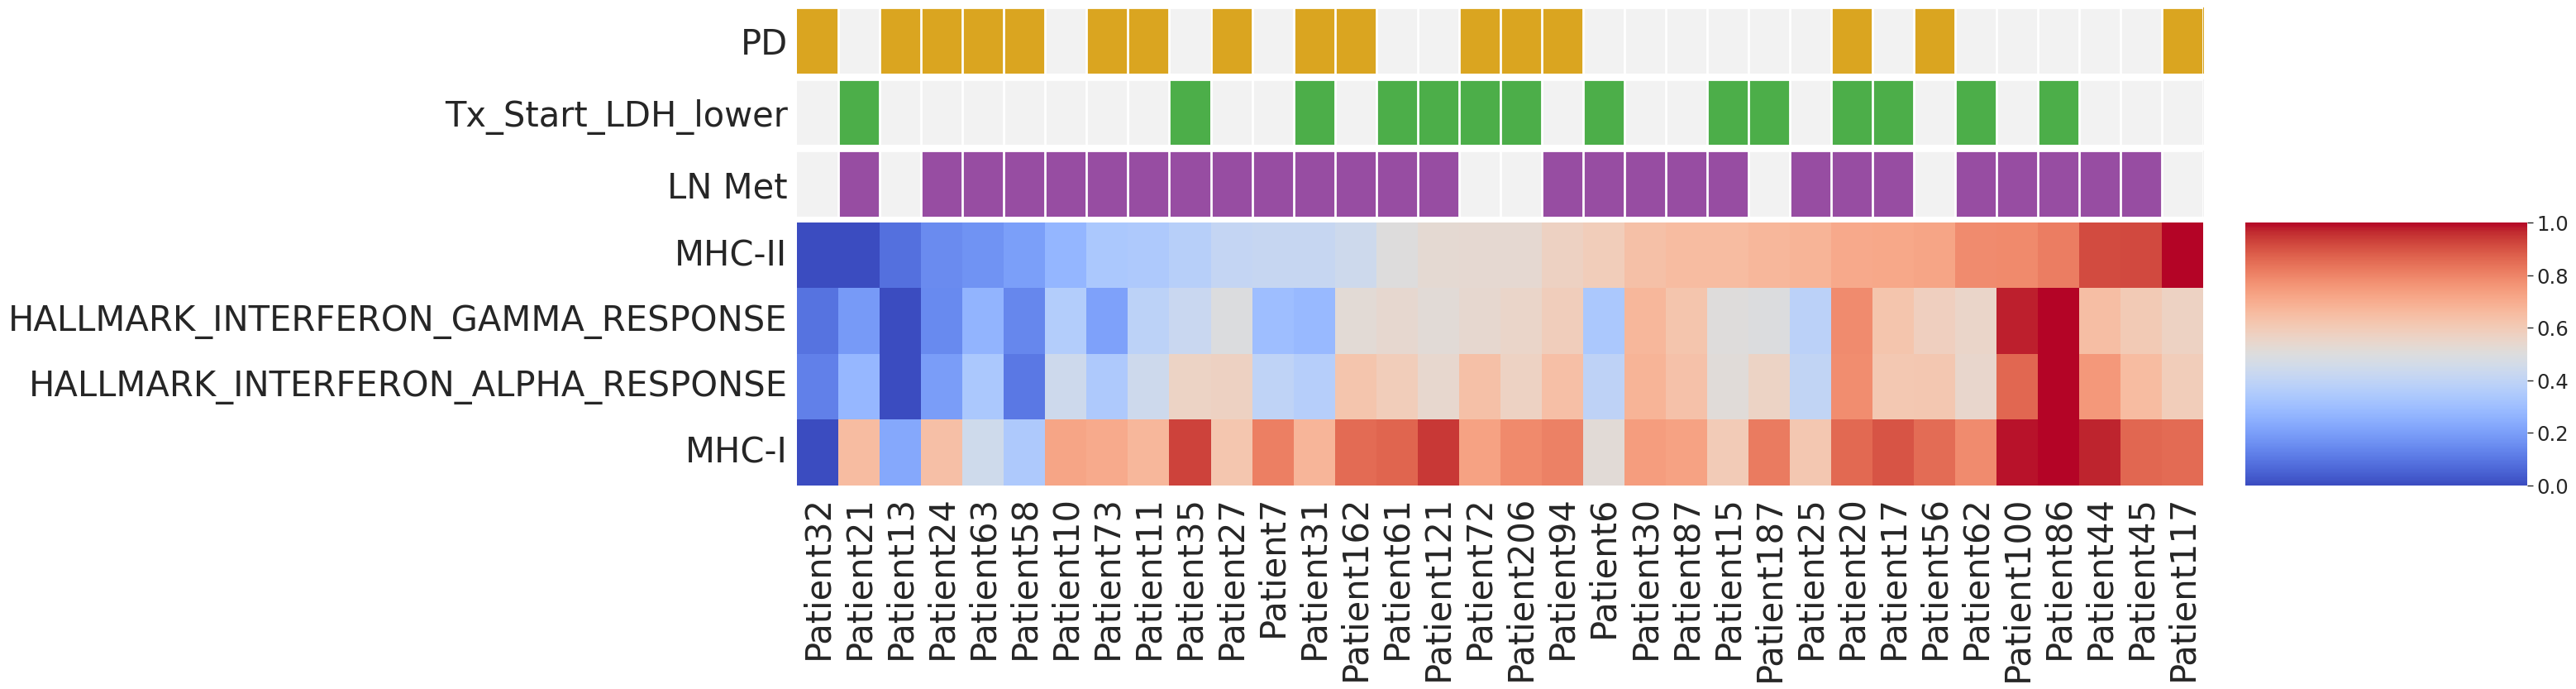

In [543]:
# Fig 5a - features that predict PD in the ipi-experienced cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-exp PD vs nPD'
geneSet = ['MHC-II', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_INTERFERON_ALPHA_RESPONSE',
          'MHC-I']
additionalFeatures = ['Tx_Start_LDH_lower', 'LN_Met_1.0']
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#graph order by variable values
orderGenes = ['MHC-II']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots

#reorder the geneSet
graphDF = df.iloc[sampleOrder][geneSet].transpose()

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']
groupDF.loc['LN Met'] = fullDF.loc[samples]['LN_Met']

groupDF.loc['Tx_Start_LDH_lower'] = df.iloc[sampleOrder]['Tx_Start_LDH_lower']
groupDF.loc['Tx_Start_LDH_lower_null'] = fullDF.loc[samples]['Tx_Start_LDH'].isin(['unknown'])

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 4
height_ratios = [1,1,1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[3,0])
cbarPlot = plt.subplot(gs[3,1])
sns.heatmap(graphDF, ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30) 
plt.setp(heatmapPlot.get_xticklabels(), size=30) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

# generate LDH plot
ldhPlot = plt.subplot(gs[1,0])
CreateCoMutFig(ldhPlot, groupDF.loc[['Tx_Start_LDH_lower']].astype(int), [GRAY, CR_COL])
# set missing values
AddMarkersCoMutFig(ldhPlot, groupDF.loc[['Tx_Start_LDH_lower_null']], [GRAY, 'black'])

plt.setp(ldhPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(ldhPlot.get_yticklabels(), size=30) 


#generate lymph node met plot
lnPlot = plt.subplot(gs[2,0])

CreateCoMutFig(lnPlot, groupDF.loc[['LN Met']].astype(int), [GRAY, LN_COL])
plt.setp(lnPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(lnPlot.get_yticklabels(), size=30)

[None]

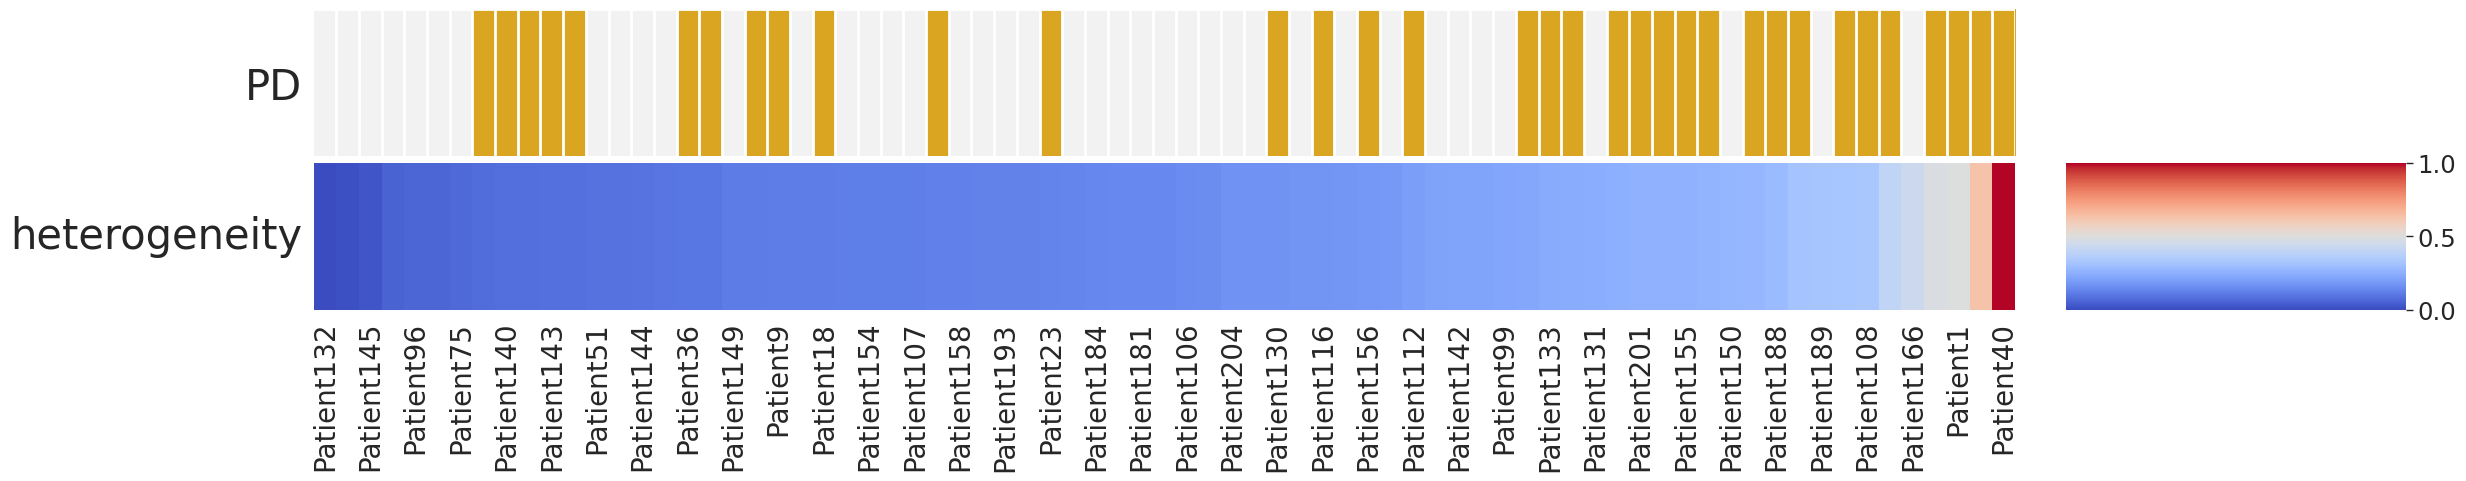

In [544]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#sample order by variable value 
orderGenes = ['heterogeneity']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['heterogeneity']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=20) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

[None]

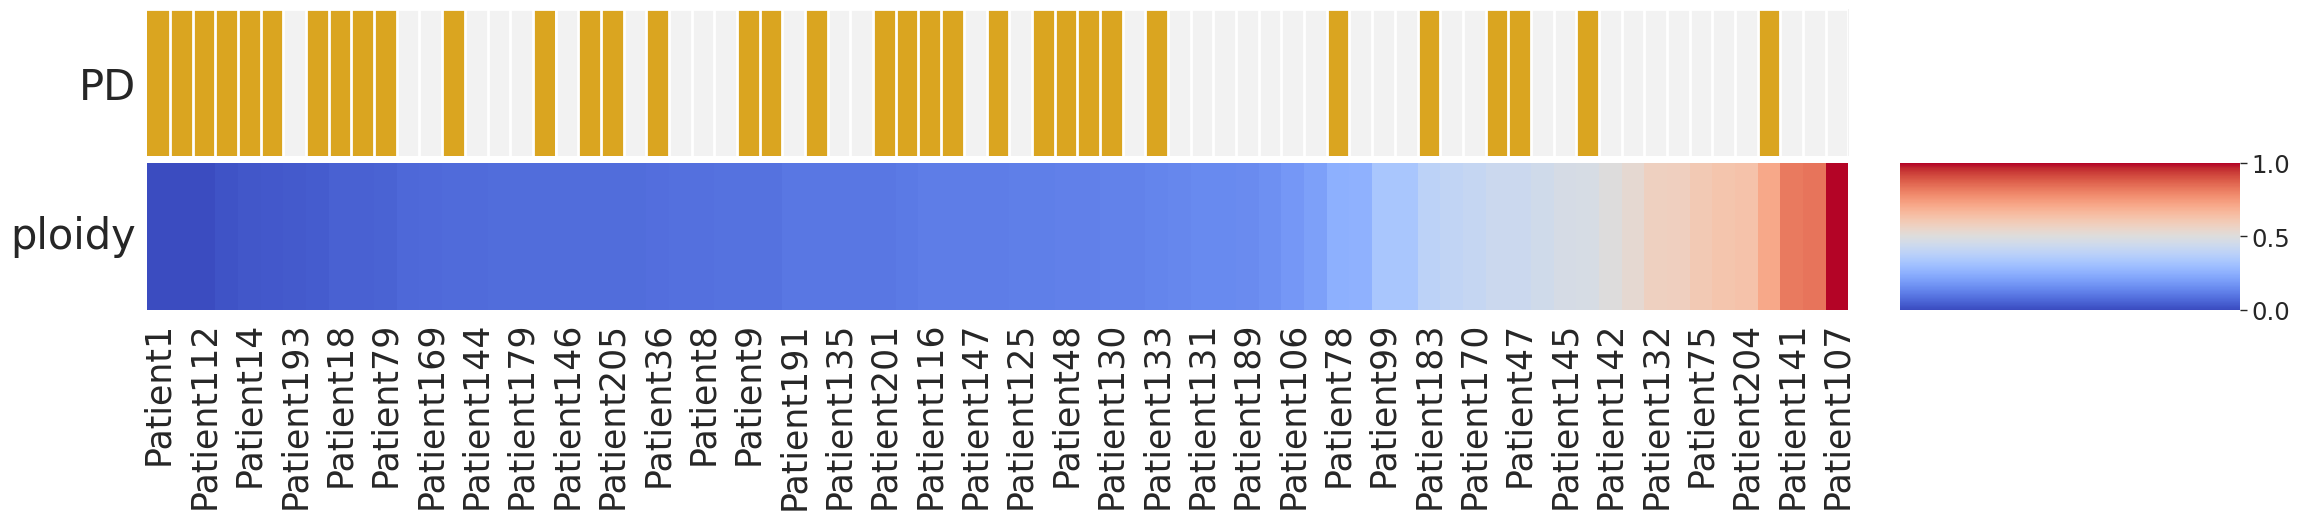

In [545]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#alternately, graph order by other variable values
orderGenes = ['ploidy']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['ploidy']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=25) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

[None]

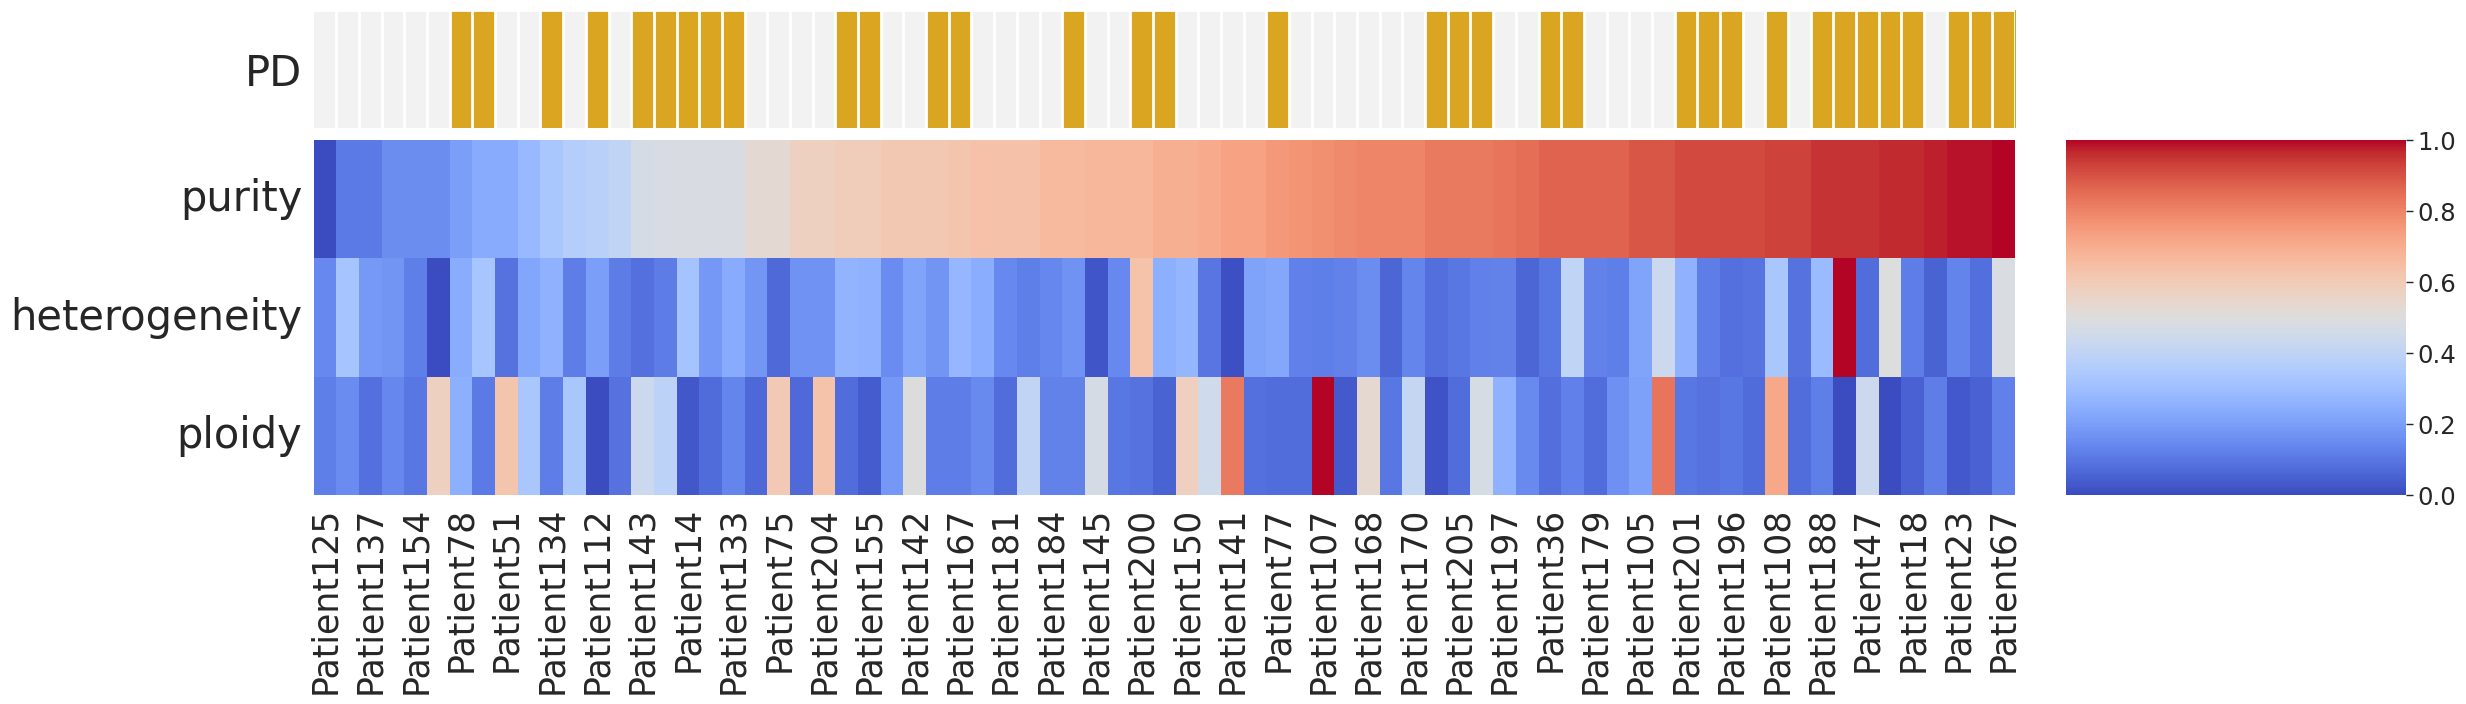

In [546]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#sample order by variable value 
orderGenes = ['purity']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['purity', 'heterogeneity', 'ploidy']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=25) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30)

Optimization terminated successfully.
         Current function value: 0.460942
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   34
Model:                          Logit   Df Residuals:                       30
Method:                           MLE   Df Model:                            3
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.3333
Time:                        23:53:33   Log-Likelihood:                -15.672
converged:                       True   LL-Null:                       -23.508
Covariance Type:            nonrobust   LLR p-value:                  0.001324
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
MHC-II                -0.0204      0.010     -2.142      0.032      -0.039      -0.002
LN_Me

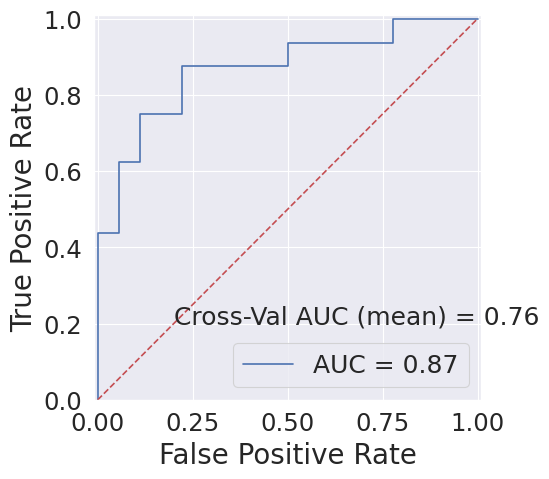

In [507]:
# Fig 5b - ROC and AUC for ipi-experienced model
outcomes = ['Ipi-exp PD vs nPD']
features = [
             'MHC-II',
                'LN_Met_1.0',
            'Tx_Start_LDH_lower',
           ]

figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

for i, outcome in enumerate(outcomes):
    regDF = fullRegDFs[outcome]
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features + ['intercept']])
    result = logitModel.fit()
    print(result.summary())
    auc = roc_auc_score(df['outcome'], result.predict(df[features + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features + ['intercept']]))
    crossval_scores = cross_val_score(LogisticRegression(), df[features + ['intercept']], 
                                      df['outcome'], scoring='roc_auc', cv=5)
    print(crossval_scores, crossval_scores.mean())

    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.text(0.2,0.2,"\nCross-Val AUC (mean) = %0.2f" % crossval_scores.mean(),size=18)

Optimization terminated successfully.
         Current function value: 0.531183
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   75
Model:                          Logit   Df Residuals:                       71
Method:                           MLE   Df Model:                            3
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                  0.2288
Time:                        23:53:34   Log-Likelihood:                -39.839
converged:                       True   LL-Null:                       -51.659
Covariance Type:            nonrobust   LLR p-value:                 2.969e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
purity            2.6840      1.370      1.959      0.050      -0.001       5.369
ploidy           -1.

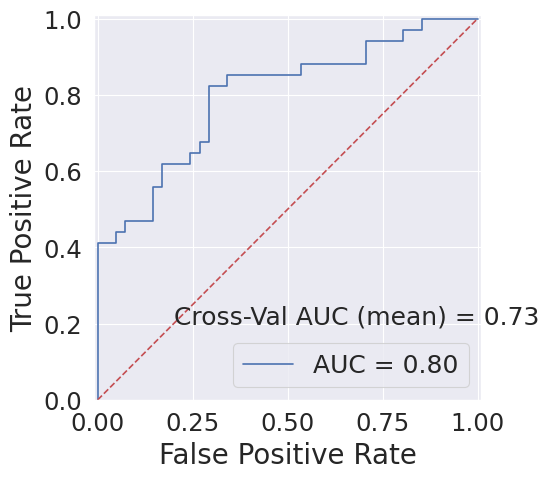

In [508]:
# Fig 5d - ROC and AUC for ipi-naive model
outcomes = ['Ipi-naive PD vs nPD']
features = [
             'purity',
                'ploidy',
            'heterogeneity',
           ]

figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

tempRegDF = fullDF.copy()
tempRegDF['outcome'] = 0
tempRegDF.loc[progressors,'outcome'] = 1
# limit to ipinaive only
tempRegDF = tempRegDF.loc[noIpi]

for i, outcome in enumerate(outcomes):
#    regDF = fullRegDFs[outcome]
    regDF = tempRegDF
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features + ['intercept']])
    result = logitModel.fit()
    print(result.summary())
    auc = roc_auc_score(df['outcome'], result.predict(df[features + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features + ['intercept']]))
    crossval_mean = 0.73
    
    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.text(0.2,0.2,"\nCross-Val AUC (mean) = %0.2f" % crossval_mean,size=18)
    
    # cross validation auc
    crossval_scores = cross_val_score(LogisticRegression(), df[features + ['intercept']], 
                                      df['outcome'], scoring='roc_auc', cv=10)
    print(crossval_scores, crossval_scores.mean())

Optimization terminated successfully.
         Current function value: 0.460942
         Iterations 7
AUC: 0.8680555555555556
Optimization terminated successfully.
         Current function value: 0.531183
         Iterations 7
AUC: 0.7991391678622668


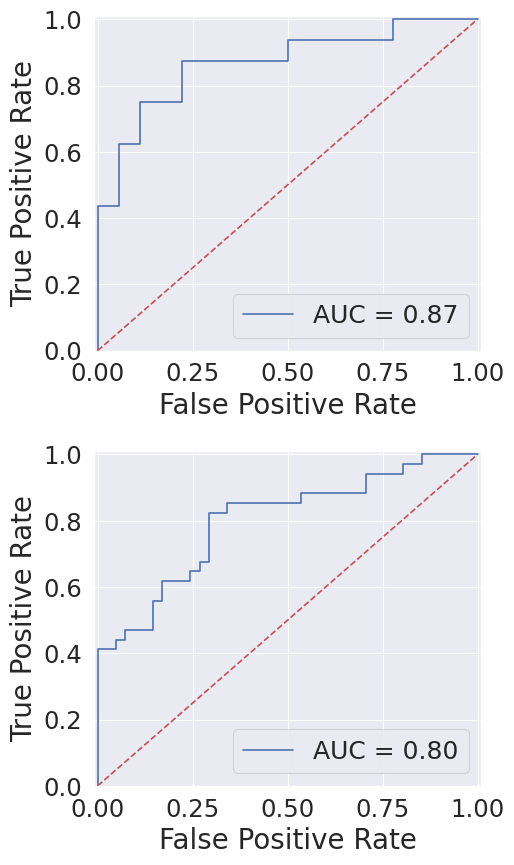

In [510]:
# Generate model scores for each outcome and model
modelScores = {}
# models applied across all tumors, split out by outcome which indicates the specific model
allTumorScores = {}

# Generate the models and AUCs for our current cohort 
outcomes = ['Ipi-exp PD vs nPD', 
            'Ipi-naive PD vs nPD']
features = {'Ipi-exp PD vs nPD': ['MHC-II', 'LN_Met_1.0', 'Tx_Start_LDH_lower'],
            'Ipi-naive PD vs nPD': ['heterogeneity', 'ploidy', 'purity']}

# since the ipi-naive model uses only genomic features, use all available tumors
tempRegDF = fullDF.copy()
tempRegDF['outcome'] = 0
tempRegDF.loc[progressors,'outcome'] = 1
# limit to ipinaive only
tempRegDF = tempRegDF.loc[noIpi]
genomicRegDF={'Ipi-naive PD vs nPD':tempRegDF}

cohorts = {'Ipi-exp PD vs nPD': fullRegDFs,
          'Ipi-naive PD vs nPD': genomicRegDF}


figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

for i, outcome in enumerate(outcomes):
    regDF = cohorts[outcome][outcome] 
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features[outcome]:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features[outcome] + ['intercept']])
    result = logitModel.fit()
    auc = roc_auc_score(df['outcome'], result.predict(df[features[outcome] + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features[outcome] + ['intercept']]))

    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    
    # save scores off
    modelScores[outcome] = result.predict(df[features[outcome] + ['intercept']])
    allTumorScores[outcome] = result.predict(fullRegDFs['PD vs nPD'][features[outcome] + ['intercept']])

In [511]:
outcomes = ['Ipi-naive PD vs nPD',
           'Ipi-exp PD vs nPD']
ipiNaive = modelScores['Ipi-naive PD vs nPD']
ipiNaiveUpper = ipiNaive[ipiNaive>=ipiNaive.median()].index
ipiNaiveLower = ipiNaive[ipiNaive<ipiNaive.median()].index

print(len(ipiNaiveUpper), len(ipiNaiveLower))

ipiExp = modelScores['Ipi-exp PD vs nPD']
ipiExpUpper = ipiExp[ipiExp>=ipiExp.median()].index
ipiExpLower = ipiExp[ipiExp<ipiExp.median()].index
print(len(ipiExpUpper), len(ipiExpLower))

38 37
17 17


In [512]:
# SURVIVAL ANALYSIS PLOTTING FUNCTIONS: copied from github/lifelines and edited for customization
def is_latex_enabled(): 
    '''
    Returns True if LaTeX is enabled in matplotlib's rcParams,
    False otherwise
    '''
    import matplotlib as mpl

    return mpl.rcParams['text.usetex']


def remove_spines(ax, sides):
    '''
    Remove spines of axis.
    Parameters:
      ax: axes to operate on
      sides: list of sides: top, left, bottom, right
    Examples:
    removespines(ax, ['top'])
    removespines(ax, ['top', 'bottom', 'right', 'left'])
    '''
    for side in sides:
        ax.spines[side].set_visible(False)
    return ax


def move_spines(ax, sides, dists):
    '''
    Move the entire spine relative to the figure.
    Parameters:
      ax: axes to operate on
      sides: list of sides to move. Sides: top, left, bottom, right
      dists: list of float distances to move. Should match sides in length.
    Example:
    move_spines(ax, sides=['left', 'bottom'], dists=[-0.02, 0.1])
    '''
    for side, dist in zip(sides, dists):
        ax.spines[side].set_position(('axes', dist))
    return ax


def remove_ticks(ax, x=False, y=False):
    '''
    Remove ticks from axis.
    Parameters:
      ax: axes to work on
      x: if True, remove xticks. Default False.
      y: if True, remove yticks. Default False.
    Examples:
    removeticks(ax, x=True)
    removeticks(ax, x=True, y=True)
    '''
    if x:
        ax.xaxis.set_ticks_position('none')
    if y:
        ax.yaxis.set_ticks_position('none')
    return ax

def add_at_risk_counts_CUSTOM(*fitters, **kwargs): 
    '''
    Add counts showing how many individuals were at risk at each time point in
    survival/hazard plots.
    Arguments:
      One or several fitters, for example KaplanMeierFitter,
      NelsonAalenFitter, etc...
    Keyword arguments (all optional):
      ax: The axes to add the labels to. Default is the current axes.
      fig: The figure of the axes. Default is the current figure.
      labels: The labels to use for the fitters. Default is whatever was
              specified in the fitters' fit-function. Giving 'None' will
              hide fitter labels.
    Returns:
      ax: The axes which was used.
    Examples:
        # First train some fitters and plot them
        fig = plt.figure()
        ax = plt.subplot(111)
        f1 = KaplanMeierFitter()
        f1.fit(data)
        f1.plot(ax=ax)
        f2 = KaplanMeierFitter()
        f2.fit(data)
        f2.plot(ax=ax)
        # There are equivalent
        add_at_risk_counts(f1, f2)
        add_at_risk_counts(f1, f2, ax=ax, fig=fig)
        # This overrides the labels
        add_at_risk_counts(f1, f2, labels=['fitter one', 'fitter two'])
        # This hides the labels
        add_at_risk_counts(f1, f2, labels=None)
    '''
    from matplotlib import pyplot as plt

    # Axes and Figure can't be None
    ax = kwargs.get('ax', None)
    if ax is None:
        ax = plt.gca()

    fig = kwargs.get('fig', None)
    if fig is None:
        fig = plt.gcf()

    fontsize = kwargs.get('fontsize', None)
    if fontsize is None:
        fontsize = 15
        
    if 'labels' not in kwargs:
        labels = [f._label for f in fitters]
    else:
        # Allow None, in which case no labels should be used
        labels = kwargs['labels']
        if labels is None:
            labels = [None] * len(fitters)
    # Create another axes where we can put size ticks
    ax2 = plt.twiny(ax=ax)
    # Move the ticks below existing axes
    # Appropriate length scaled for 6 inches. Adjust for figure size.
    ax2_ypos = -0.20 * 6.0 / fig.get_figheight()
    move_spines(ax2, ['bottom'], [ax2_ypos])
    # Hide all fluff
    remove_spines(ax2, ['top', 'right', 'bottom', 'left'])
    # Set ticks and labels on bottom
    ax2.xaxis.tick_bottom()
    # Match tick numbers and locations
    ax2.set_xticks(ax.get_xticks())
    ax2.set_xlim(ax.get_xlim())
    
    # Remove ticks, need to do this AFTER moving the ticks
    remove_ticks(ax2, x=True, y=True)
    # Add population size at times
    ticklabels = []
    for tick in ax2.get_xticks():
        lbl = ""
        for f, l in zip(fitters, labels):
            # First tick is prepended with the label
            if tick == ax2.get_xticks()[0] and l is not None:
                if is_latex_enabled():
                    s = "\n{}\\quad".format(l) + "{}"
                else:
                    s = "\n{}   ".format(l) + "{}"
            else:
                s = "\n{}"
            lbl += s.format(f.durations[f.durations >= tick].shape[0])
        ticklabels.append(lbl.strip())
    # Align labels to the right so numbers can be compared easily
    print(ticklabels)
    ax2.set_xticklabels(ticklabels, ha='right', fontsize=15)

    # Add a descriptive headline.
    ax2.xaxis.set_label_coords(0, ax2_ypos)
    ax2.set_xlabel('At risk', fontsize=15)

    plt.tight_layout()
    return ax2

Low Model Score : 17
High Model Score : 17
[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
['Low Model Score   17\nHigh Model Score   17', '9\n2', '9\n2', '8\n1', '3\n0', '1\n0', '0\n0']


/tmp/ipykernel_489612/800951444.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
           8.96 <0.005      8.50

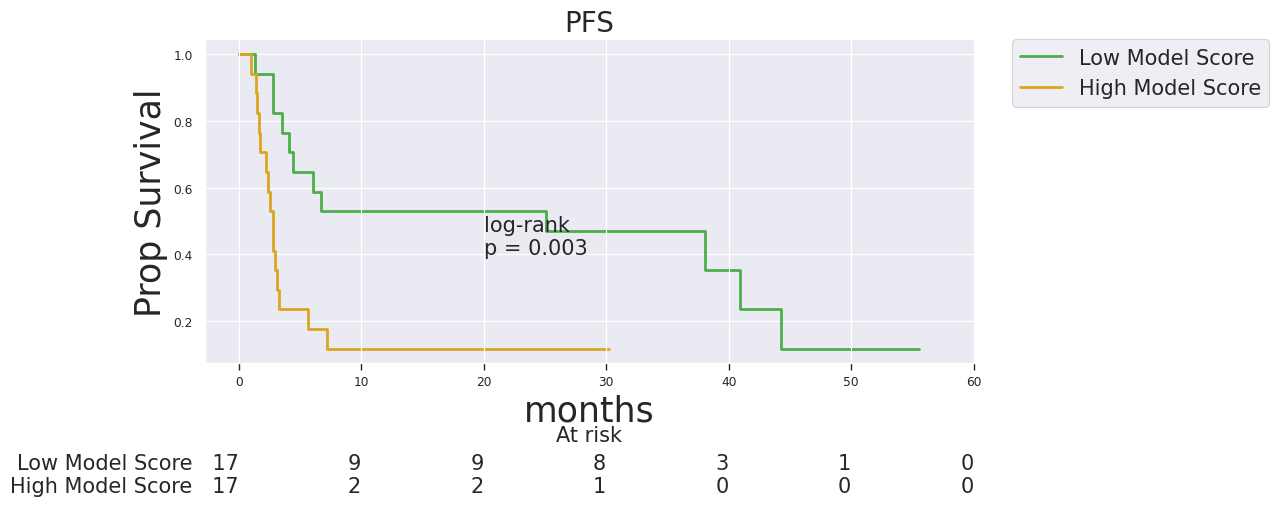

In [513]:
# Fig 5e - survival of model score-high and model score-low ipi-experienced tumors
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

#survival = 'OS'
survival = 'PFS'
#event = 'dead'
event = 'progressed'

sns.set_context("paper",font_scale=1)

groups = [ipiExpLower,ipiExpUpper]
#groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    print(labels[i], ":", len(group))
    # print(survival,"median", kmf.median_)
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
print(newxticks)
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

Low Model Score : 17
High Model Score : 17
[0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
['Low Model Score   17\nHigh Model Score   17', '13\n7', '12\n4', '10\n2', '4\n0', '1\n0', '0\n0']


/tmp/ipykernel_489612/859139261.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           6.98 0.01      6.92

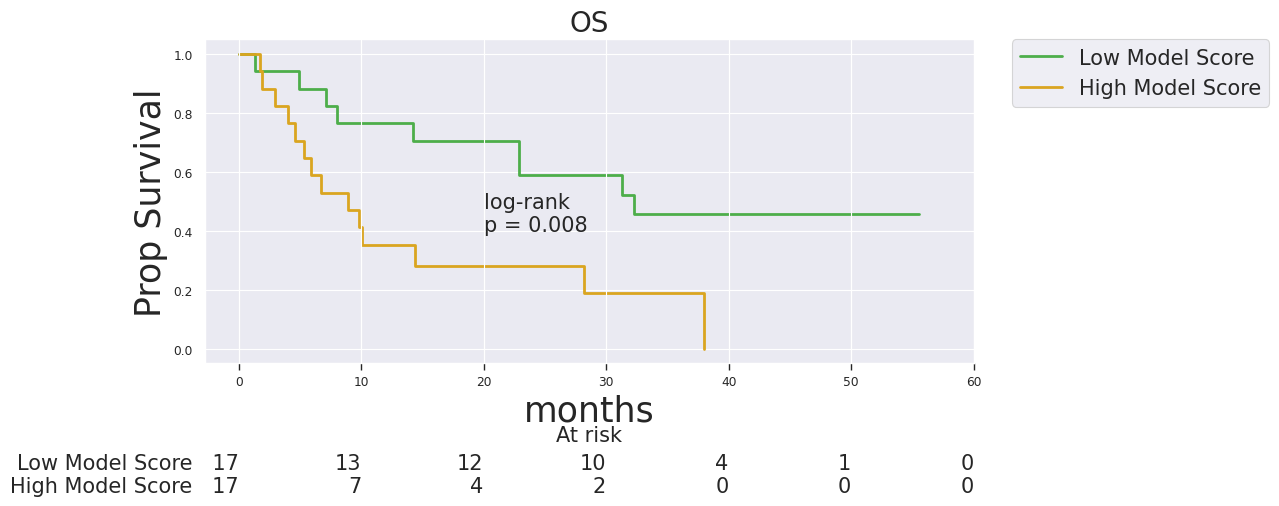

In [514]:
survival = 'OS'
#survival = 'PFS'
event = 'dead'
#event = 'progressed'

sns.set_context("paper",font_scale=1)

groups = [ipiExpLower,ipiExpUpper]
#groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    print(labels[i], ":", len(group))
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
print(newxticks)
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

['Low Model Score   37\nHigh Model Score   38', '29\n12', '23\n9', '19\n6', '16\n4', '11\n2', '4\n1', '0\n0']


/tmp/ipykernel_489612/460001644.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.8, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          13.07 <0.005     11.71

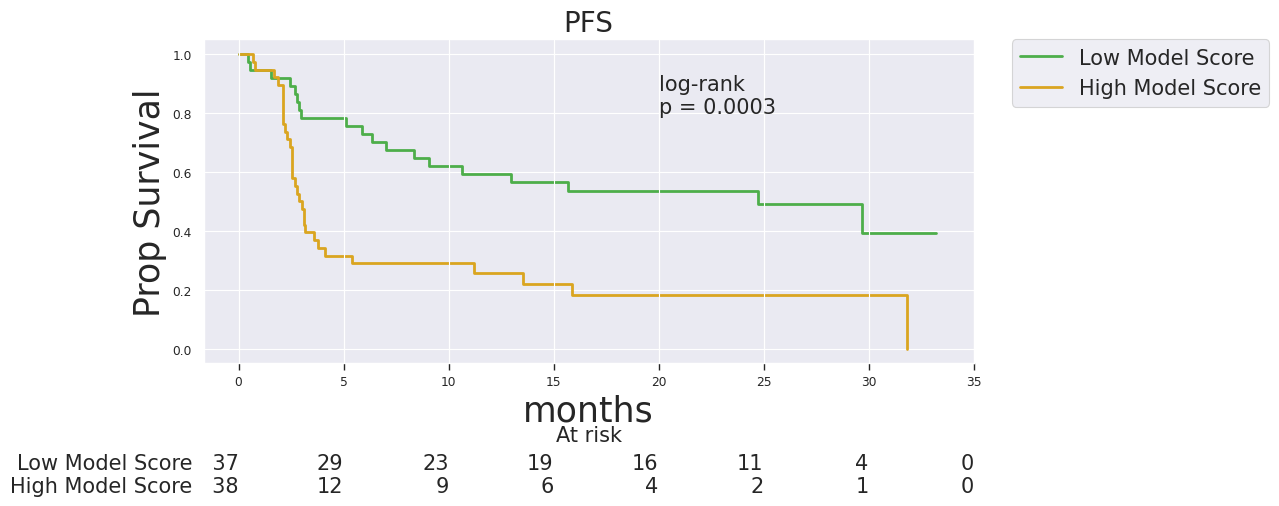

In [515]:
# Fig 5f - survival of model score-high and model score-low ipi-naive tumors

#survival = 'OS'
survival = 'PFS'
#event = 'dead'
event = 'progressed'

sns.set_context("paper",font_scale=1)

#groups = [ipiExpLower,ipiExpUpper]
groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    # print labels[i], ":", len(group)
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
# print newxticks
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.8, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

['Low Model Score   37\nHigh Model Score   38', '32\n22', '25\n11', '9\n3', '1\n0', '1\n0', '0\n0']


/tmp/ipykernel_489612/4135133268.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.6, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          15.87 <0.005     13.84

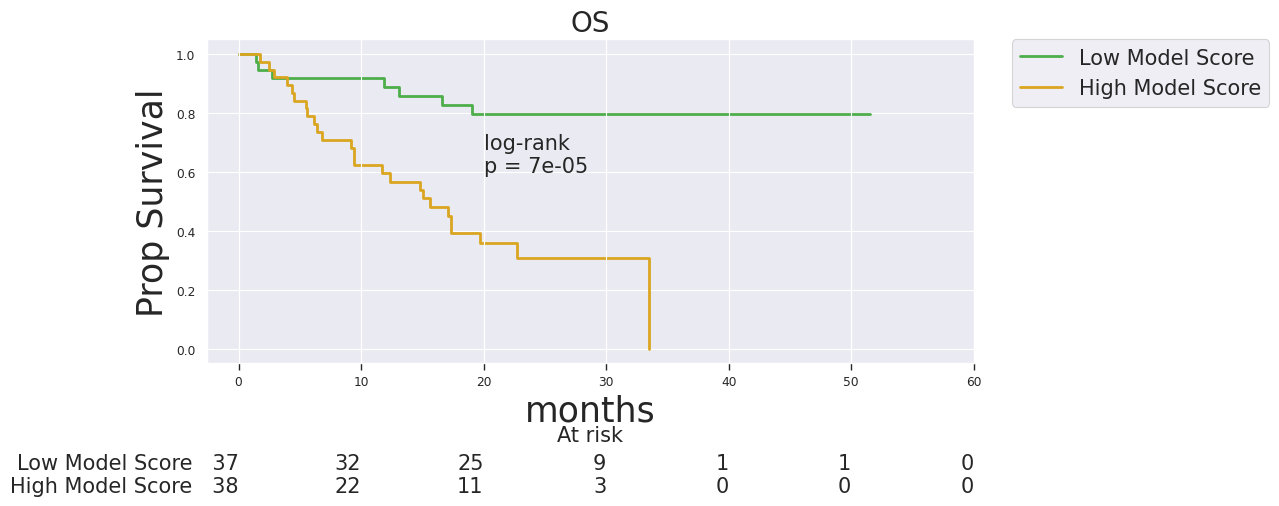

In [517]:
# Fig 5f - survival of model score-high and model score-low ipi-naive tumors

survival = 'OS'
#survival = 'PFS'
event = 'dead'
#event = 'progressed'

sns.set_context("paper",font_scale=1)

#groups = [ipiExpLower,ipiExpUpper]
groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    # print labels[i], ":", len(group)
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
# print newxticks
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.6, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()